In [18]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

In [19]:
#load dataset
df = pd.read_csv("Mall_Customers[1].csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [20]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

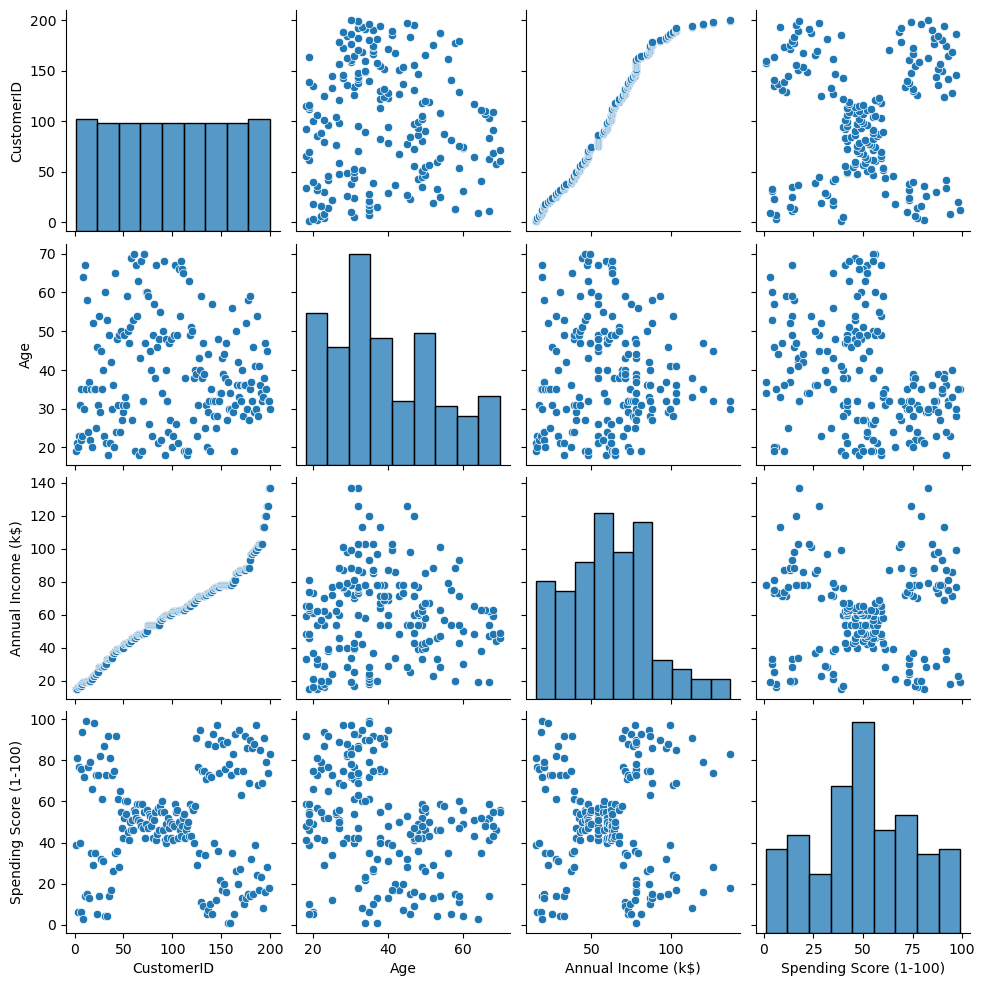

In [21]:
sns.pairplot(df)
plt.show()

In [22]:
x = df.iloc[:, [3,4]]

In [23]:
wcss=[]

for i in range(1,11):

    model=KMeans(n_clusters=i,
                 init='k-means++',
                 random_state=42)

    model.fit(x)

    wcss.append(model.inertia_)

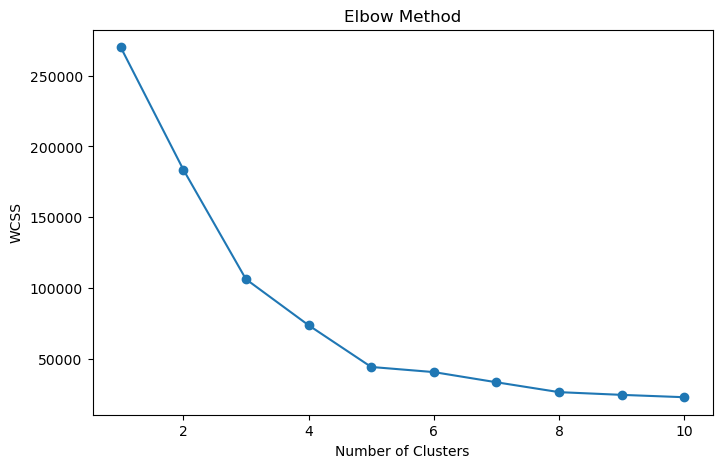

In [24]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [25]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

y_pred = kmeans.fit_predict(x)

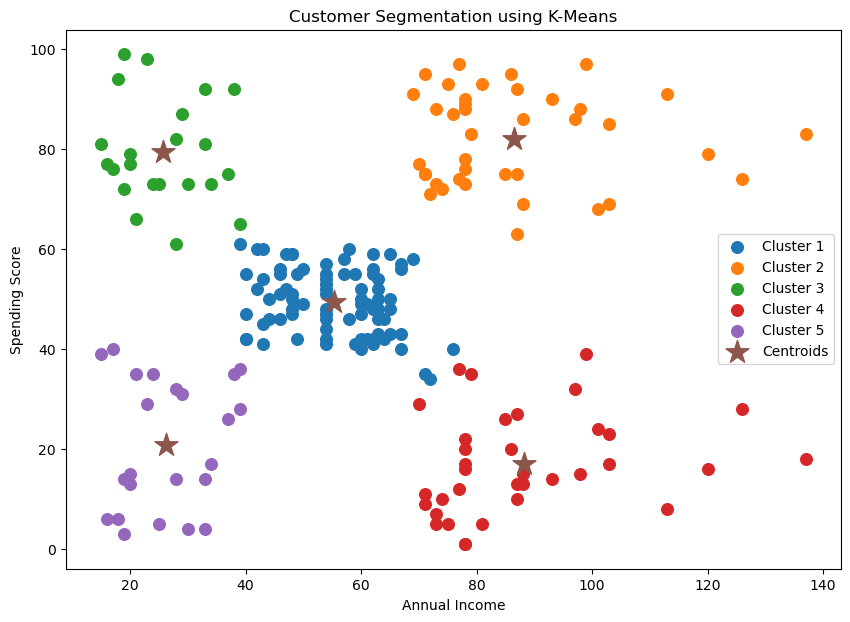

In [26]:
plt.figure(figsize=(10,7))

plt.scatter(
    x.iloc[y_pred==0,0],
    x.iloc[y_pred==0,1],
    s=70,
    label='Cluster 1'
)

plt.scatter(
    x.iloc[y_pred==1,0],
    x.iloc[y_pred==1,1],
    s=70,
    label='Cluster 2'
)

plt.scatter(
    x.iloc[y_pred==2,0],
    x.iloc[y_pred==2,1],
    s=70,
    label='Cluster 3'
)

plt.scatter(
    x.iloc[y_pred==3,0],
    x.iloc[y_pred==3,1],
    s=70,
    label='Cluster 4'
)

plt.scatter(
    x.iloc[y_pred==4,0],
    x.iloc[y_pred==4,1],
    s=70,
    label='Cluster 5'
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    marker='*',
    label='Centroids'
)

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.title("Customer Segmentation using K-Means")

plt.legend()

plt.show()

In [27]:
df["Cluster"] = y_pred

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [29]:
df.to_csv("Customer_Segmentation_Output.csv",index=False)